# Coursework Set week 4

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Jesse van der Meulen
* Username: jrhmeulen
* Student number: S6445128
* Group (AS1, etc.): AS1

-----

In [1]:
totalpoints = currentpoints = 0

### Monte Carlo Error Propagation (4 pt) <font color='red'><b>COURSEWORK</b></font>

One of the classical Physic Lab experiment is to use pendulum to calculate the local gravitational acceleration, ``g``, from the measurements of the pendulum length ``L`` and the oscillation period ``T``.

The formula is expressed as follows:

$$ g=\frac{4\pi^2 L}{T^2} $$

You have got a set of measurements of $L=1.00\pm0.01\ \mathrm{(m)}$ and $T=2.01\pm0.02\ \mathrm{(s)}$.

* Like in Physics Lab, use Tyler expansion described above to propagate the error. Write your derivation in Markdown.

* Calculate the error of the derived ``g``.

* Apply Monte Carlo error propagation to estimate the value and uncertainty of ``g``.

* Make appropriate comments.

* Compare the two results.

# Monte Carlo Error Propagation: Derivation

$$g(L, T) = \frac{4\pi^2 L}{T^2}$$

$$\sigma_g = \sqrt{ \left( \frac{\partial g}{\partial L} \sigma_L \right)^2 + \left( \frac{\partial g}{\partial T} \sigma_T \right)^2 }$$

Partial derivative with respect to $L$:
$$\frac{\partial g}{\partial L} = \frac{4\pi^2}{T^2}$$

Partial derivative with respect to $T$:
$$\frac{\partial g}{\partial T} = -\frac{8\pi^2 L}{T^3}$$

The final expression for the error in $g$ is:
$$\sigma_g = g \cdot \sqrt{ \left( \frac{\sigma_L}{L} \right)^2 + \left( \frac{2\sigma_T}{T} \right)^2 }$$


In [2]:
import numpy as np
#list all data
L = 1.00
l=0.01
T=2.01
t=0.02
#now the formula for g
g=(4*np.pi**2*L)/(T**2)
#the formula for the error in g
G=g*np.sqrt((l/L)**2 + (2*t/T)**2)
print(f'The derived g and its error: g= {g:.3f} ± {G:.3f}')
#now for the monte carlo approximation
N=1000000
#distributions
Ls = np.random.normal(L, l, N)
Ts = np.random.normal(T, t, N)
#formula
gs = (4*np.pi**2*Ls)/(Ts**2)
#finish the equation
MCg= np.mean(gs)
MCG=np.std(gs)
print(f'Monte Carlo: {MCg:.3f} ± {MCG:.3f}')

The derived g and its error: g= 9.772 ± 0.218
Monte Carlo: 9.775 ± 0.218


In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Complex roots of a quadratic equation (4 pt) <font color='red'><b>COURSEWORK</b></font>
  
Use the information in the notebook about complex numbers to write a program that can calculate the (complex) roots of a quadratic equation with the quadratic formula:

$$ y=ax^2+bx+c $$

The requirement of this program is as follows:

* User can supply constants ``a``, ``b`` and ``c`` with Python function `input()`.
* The program can deal with complex roots.
* Your program must print the equation with its constants and its roots.
* The solutions must be inserted to the original equation to prove that $f(x)=0$.

**Answer**:

In [ ]:
import numpy as np
a= float(input('Input desired value for a: '))
b= float(input('Input desired value for b: '))
c= float(input('Input desired value for c: '))
D=b**2 - 4*a*c
if D>=0:
    x1 = (-b + np.sqrt(D))/(2*a)
    x2 = (-b - np.sqrt(D))/(2*a)
else:
    real = -b/(2*a)
    imag = (np.sqrt(abs(D)))/(2*a)
    x1 = real + 1j*imag
    x2 = real - 1j*imag
print(f'The equation using the input values for the constants: f(x)={a}x^2 + {b}x + {c}')
print(f'The first solution yields: root 1 = {x1}')
print(f"the second solution yields: root 2 = {x2}")
P1=a*(x1**2) + b*x1 + c
P2=a*(x2**2) + b*x2 + c
print(f'The first solution yields f(x)={P1}')
print(f'The second solution yields f(x)={P2}')

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Area under a Gaussian (6 pt) <font color='red'><b>COURSEWORK</b></font>

A one dimensional Gaussian function is given by:

$$f(x) = A\ e^{\frac{-{(x-x_0)}^2}{2 \sigma^2}} + z_0$$

$A$ is the amplitude, $x_0$ is the position of the peak, $\sigma$ is the width of the peak
and $z_0$ is the offset in $y$.  

This function can be written in Python as follows:

```python
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0
```

1. Set in the calling environment:
```python
    A = 1.0
    x0 = 0.0
    sig = 2.0
    z0 = 0.0
```
2. Plot this function between -10 and 10 with 200 samples.
3. Use function `scipy.integrate.quad()` to find the area between ``x=0`` and ``x=2.5``.
4. Use function `matplotlib.pyplot.fill_between()` to mark that area in your plot.
5. Calculate the area between $-\infty$ and $\infty$ ($\approx 5.01$).
6. Given is the integral for the total area under the curve:

    $$\int _{-\infty }^{\infty }Ae^{-(x-x_0)^{2}/(2\sigma^{2})}\,\mathrm{d}x=A \sigma \cdot {\sqrt {2\pi }}$$

   Calculate this area for the values of the parameters given above and prove with ``quad()`` that the two are the same.

7. Make the last part an executable script, called ``gaussarea``. The user can enter values for ``A``, ``x0``, ``sig`` and ``z0`` and the integration limits. The programme then calculates the area under the curve between the integration limits using function ``quad()``. The programme must includes a plot of the curve, the integration area, and the value of that area in a legend.
8. Insert the generated plot in a separate markdown cell below your code cell, and upload your script to GitHub. Provide your GitHub website link in the notebook too for TA to check. 
   
**Answers**:   

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

def Gaus(x, A, x0, sigma, z0):
    return A*np.exp(-(x - x0)**2 / (2*sigma**2)) + z0
A=1
x0=0
sigma=2
z0=0
x=np.linspace(-10, 10, 200)
y= Gaus(x, A, x0, sigma, z0)
Area, _ = quad(Gaus, 0, 2.5, args=(A, x0, sigma, z0))

plt.plot(x, y, label='Gausian curve')
X = np.linspace(0, 2.5, 100)
Y = Gaus(X, A, x0, sigma, z0)
plt.fill_between(X, Y, color='Skyblue', alpha=0.5, label='Area')
TaQ, _ = quad(Gaus, -np.inf, np.inf, args=(A, x0, sigma, z0))
TaF = A*sigma*np.sqrt(2*np.pi)

print(f'The area in the given bounds: {Area:.4f}')
print(f'Total quad area: {TaQ:.4f}')
print(f'Total area with formula: {TaF:.4f}')
plt.legend()
plt.grid(True)
plt.show()

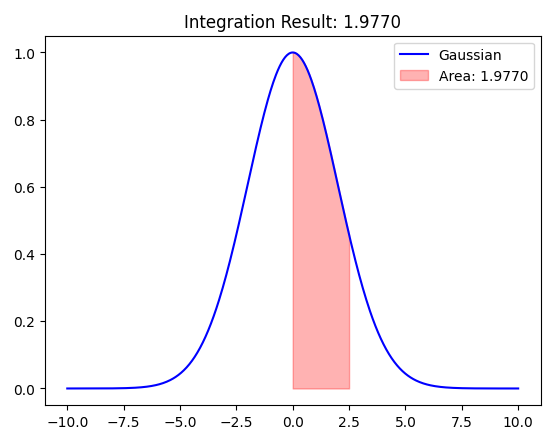

the github link:
https://github.com/JesseMoilen/PROGNUM-repo/tree/main/Task4

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Calculate integral of a user supplied function (6 pt) <font color='red'><b>COURSEWORK</b></font>

Write a programme that calculates the integral of any function from the user input using ``eval()``, which is a string representing a function and a variable (floating number) for which the function will be evaluated.

* Call from ``numpy import sin, cos, exp, pi`` to apply these functions and constants in your code.
* Use ``scipy.integrate.quad()`` to calculate the integral of the formula below between $x=0$ and $x=\pi$
* Use Monte Carlo Integration to calculate the integral of the formula below for $x=0$ and $x=\pi$

$$ f(x)=x^4+e^{\sin{x}+\cos{x}} $$

Make the function robust with try/except clauses. Demonstrate exceptions for wrong expressions and unknown functions in an expression (NameError) etc. Print messages that tell a user what they have done wrong!

Make the above code an executable script called ``interate_user_function``, and upload to GitHub.

* Create a separate cell, and use SymPy expression to calculate the integral of the formula below for $x=0$ and $x=\pi$.

In [ ]:
import numpy as np
from numpy import sin, cos, e, pi
from scipy.integrate import quad

def Inty():
    expr = input('enter desired functoin f(x): ')
    a, b = 0, pi
    def f(xv):
        try:
            return eval(expr, {"x": xv, "sin": sin, "cos": cos, "e": e, "pi": pi})
        except NameError as er:
            raise NameError(f"Unknown function or variable: {er}")
        except SyntaxError:
            raise SyntaxError("Invalid syntax in expression.")
        except Exception as er:
            raise Exception(f"Evaluation error: {er}")
    try:
        sq_res, _ = quad(f, a, b)
        N = 100000
        X = np.random.uniform(a, b, N)
        F = np.array([f(val) for val in X])
        MC = (b - a) * np.mean(F)
        print(f"SciPy Result: {sq_res}")
        print(f"Monte Carlo Result: {MC}")
    except (NameError, SyntaxError, Exception) as er:
        print(f'error: {er}')
if __name__ == "__main__":
    Inty()

In [ ]:
import sympy as sp

x = sp.symbols('x')
f = x**4 + sp.exp(sp.sin(x) + sp.cos(x))

result = sp.integrate(f, (x, 0, sp.pi)).evalf()

print(result)

the github link: https://github.com/JesseMoilen/PROGNUM-repo/tree/main/Task4

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Hertzsprung–Russell (HR) diagram (6 pt) <font color='red'><b>COURSEWORK</b></font>

``Hertzsprung-Russell (HR) diagram``, which indicates the stellar evolution, is an important astrophysical plot graphing stellar luminosity (brightness, absolute magnitude) against surface temperature (or colour). This diagram clearly states the evolutionary pathways of stars and where they are in their lifetime. With this, we classify several important stages of a star's life -- main sequence stars, giants, or white dwarfs. 

In this exercise, a combined APOGEE/Gaia star catalog has been prepared for you to create an HR diagram -- download the catalogue from the BrightSpace: ``APOGEE+Gaia_stars.fits``

* To read FITS file, you need AstroPy, which is a library that is widely used in Astronomy.

```python
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
```

* "data" is a AstroPy data class, but it can be used like a ndarray as follows.

```python
print(data[0]) # The first row of the catalogue
print(data['STARFLAG']) # List all rows in the column of "STARFLAG"
print(data['STARFLAG'][:10]) # Print the first 10 elements in the column of "STARFLAG"
print(data['STARFLAG'][-10:]) # Print the last 10 elements in the column of "STARFLAG"
```

* Firstly, let's select data with good quality and robust measurements using the following criteria:
    * STARFLAG == 0
    * ASPCAPFLAG == 0
    * SNR > 10
    * GAIAEDR3_PARALLAX/ GAIAEDR3_PARALLAX_ERROR > 5
    * GAIAEDR3_PHOT_G_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_BP_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_RP_MEAN_MAG is not NaN value

* From the selected data, let's randomly choose about **80% of the data** for plotting the HR diagram. 

* The HR diagram contains
    * $x$-axis: colour -- BP-RP
    * $y$-axis: absolute magnitude -- $M_G$


**<span style="color:red">Warning</span>**: note that from observation, we only have apparent magnitude (i.e. observed magnitude). To convert into absolute magnitude requires **Distance Modulus**: 

$$ M_G = m_G + 5\log10{(\mathrm{parallax}/1000)} + 5 $$

* Apply a rough binary classification scheme to separate giant branch and main sequence (MS) stars.
    * Giant branch: $ M_G<3.5 $ and $(BP-RP)>0.8$
    * MS: assume the rest of the data is MS

* It seems that we do not have sufficient samples in the White Dwarf (WD) region. Use the following criteria to draw vertical and horizontal lines, as well as define a box indicating the location of WD on the HR diagram.
    * $(BP-RP)\leq0.8$ and $ M_G>10 $ (very faint)
 
* Make a scatter plot and customise it to be look like the plot shown here.

<img src="attachment:14037eb3-1593-4349-8d4a-ae0bd96b6e97.png" alt="HR Diagram" width="600">

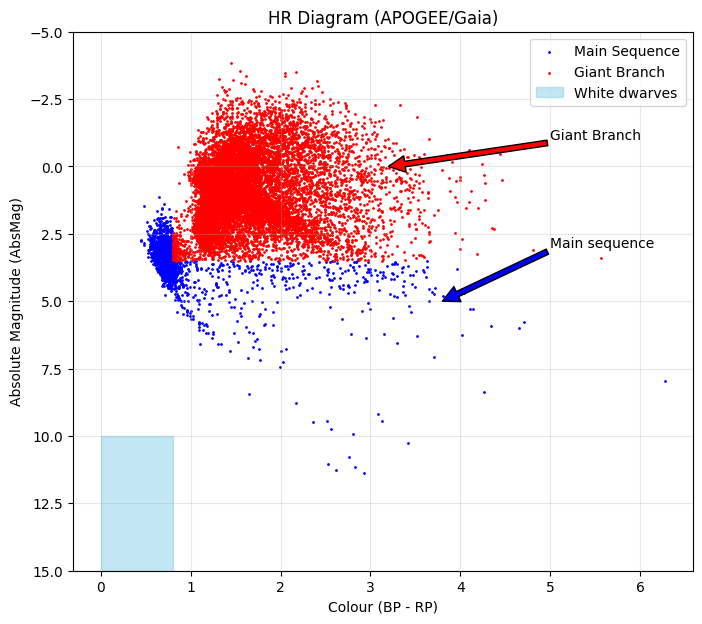

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names

Wstars = (
    (data['STARFLAG'] == 0) & 
    (data['ASPCAPFLAG'] == 0) & 
    (data['SNR'] > 10) & 
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)

DATA = data[Wstars]

indices = np.random.choice(len(DATA), size=int(0.10 * len(DATA)), replace=False)
sample = DATA[indices]

BPRP = sample['GAIAEDR3_PHOT_BP_MEAN_MAG'] - sample['GAIAEDR3_PHOT_RP_MEAN_MAG']
mag = sample['GAIAEDR3_PHOT_G_MEAN_MAG']
parallax = sample['GAIAEDR3_PARALLAX']
AbsMag = mag + 5 * np.log10(parallax / 1000) + 5

Giants = (AbsMag < 3.5) & (BPRP > 0.8)
MS = ~Giants

plt.figure(figsize=(8, 7))
plt.scatter(BPRP[MS], AbsMag[MS], s=1, color='blue', label='Main Sequence')
plt.scatter(BPRP[Giants], AbsMag[Giants], s=1, color='red', label='Giant Branch')

plt.annotate('Giant Branch', xy=(3.2,0), xytext=(5, -1), arrowprops=dict(facecolor='red'))
plt.annotate('Main sequence', xy=(3.8, 5), xytext=(5, 3), arrowprops=dict(facecolor='blue'))
XWD=[0, 0.8, 0.8, 0]
YWD=[10, 10, 15, 15]
plt.fill(XWD, YWD, color='Skyblue', alpha=0.5, label='White dwarves')

plt.ylim(-5, 15)
plt.gca().invert_yaxis()
plt.xlabel('Colour (BP - RP)')
plt.ylabel('Absolute Magnitude (AbsMag)')
plt.title('HR Diagram (APOGEE/Gaia)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")